In [16]:
!pip install -q transformers datasets accelerate evaluate

In [17]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import Dataset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [18]:
train_df = pd.read_csv('/content/train_1.csv')
test_df = pd.read_csv('/content/test_1.csv')
validation_df = pd.read_csv('/content/validation_1.csv')

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Validation:", validation_df.shape)

Train: (4494, 3)
Test: (1284, 3)
Validation: (642, 3)


In [19]:
print("TRAIN")
print(train_df['label'].value_counts())

print("\nTEST")
print(test_df['label'].value_counts())

print("\nVALIDATION")
print(validation_df['label'].value_counts())

TRAIN
label
real    2352
fake    2142
Name: count, dtype: int64

TEST
label
real    672
fake    612
Name: count, dtype: int64

VALIDATION
label
real    336
fake    306
Name: count, dtype: int64
TRAIN
label
real    2352
fake    2142
Name: count, dtype: int64

TEST
label
real    672
fake    612
Name: count, dtype: int64

VALIDATION
label
real    336
fake    306
Name: count, dtype: int64


In [20]:
def prepare_dataframe(df):
    df = df[['tweet', 'label']].copy()

    df = df.dropna(subset=['tweet', 'label'])

    df['label'] = df['label'].map({
        'fake': 0,
        'real': 1
    })

    df = df.dropna(subset=['label'])

    df['label'] = df['label'].astype(int)

    return df

train_df = prepare_dataframe(train_df)
test_df = prepare_dataframe(test_df)
validation_df = prepare_dataframe(validation_df)

print(train_df.head())

                                               tweet  label
0  The novel coronavirus can be cured by one bowl...      0
1  At the peak in New York on April 15 that state...      1
2  Video shows a huge crowd gathered in an Americ...      0
3  (2/4) Containment zones that refer to a specif...      1
4  Australian Scientists referred to coronavirus ...      0
                                               tweet  label
0  The novel coronavirus can be cured by one bowl...      0
1  At the peak in New York on April 15 that state...      1
2  Video shows a huge crowd gathered in an Americ...      0
3  (2/4) Containment zones that refer to a specif...      1
4  Australian Scientists referred to coronavirus ...      0


In [21]:
train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

validation_dataset = Dataset.from_pandas(
    validation_df.reset_index(drop=True)
)

print(train_dataset)
print(test_dataset)
print(validation_dataset)

Dataset({
    features: ['tweet', 'label'],
    num_rows: 4494
})
Dataset({
    features: ['tweet', 'label'],
    num_rows: 1284
})
Dataset({
    features: ['tweet', 'label'],
    num_rows: 642
})
Dataset({
    features: ['tweet', 'label'],
    num_rows: 4494
})
Dataset({
    features: ['tweet', 'label'],
    num_rows: 1284
})
Dataset({
    features: ['tweet', 'label'],
    num_rows: 642
})


In [22]:
model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
def tokenize_function(batch):
    return tokenizer(
        batch['tweet'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

validation_dataset = validation_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/4494 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/642 [00:00<?, ? examples/s]

Map:   0%|          | 0/4494 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/642 [00:00<?, ? examples/s]

In [24]:
train_dataset = train_dataset.remove_columns(['tweet'])
test_dataset = test_dataset.remove_columns(['tweet'])
validation_dataset = validation_dataset.remove_columns(['tweet'])

In [25]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='weighted',
        zero_division=0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [26]:
training_args = TrainingArguments(
    output_dir='/content/roberta_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=50,
    report_to='none'
)

In [27]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [28]:
train_dataset.reset_format()
test_dataset.reset_format()
validation_dataset.reset_format()

In [29]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.155469,0.122964,0.971963,0.972224,0.971963,0.971942
2,0.076668,0.104763,0.971963,0.972159,0.971963,0.971945
3,0.008315,0.109237,0.978193,0.978342,0.978193,0.978182


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=843, training_loss=0.11830841625288288, metrics={'train_runtime': 353.8445, 'train_samples_per_second': 38.101, 'train_steps_per_second': 2.382, 'total_flos': 886815812090880.0, 'train_loss': 0.11830841625288288, 'epoch': 3.0})

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.154155,0.125206,0.970405,0.970821,0.970405,0.970376
2,0.077586,0.158596,0.964953,0.966588,0.964953,0.964871
3,0.013331,0.126179,0.975078,0.975279,0.975078,0.975062


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=843, training_loss=0.12568393211772008, metrics={'train_runtime': 373.0637, 'train_samples_per_second': 36.139, 'train_steps_per_second': 2.26, 'total_flos': 886815812090880.0, 'train_loss': 0.12568393211772008, 'epoch': 3.0})

In [30]:
test_results = trainer.evaluate(test_dataset)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.013331,0.126179,3,0.975078,0.975279,0.975078,0.975062


{'eval_loss': 0.12617865204811096, 'eval_accuracy': 0.9750778816199377, 'eval_precision': 0.9752793500108761, 'eval_recall': 0.9750778816199377, 'eval_f1': 0.9750621686033225}


In [31]:
prediction_output = trainer.predict(test_dataset)

test_predictions = np.argmax(
    prediction_output.predictions,
    axis=1
)

test_true_labels = prediction_output.label_ids

In [32]:
test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

print(f"RoBERTa Test Accuracy: {test_accuracy * 100:.2f}%")

RoBERTa Test Accuracy: 97.51%


In [33]:
print(
    classification_report(
        test_true_labels,
        test_predictions,
        target_names=['Fake', 'Real'],
        digits=4
    )
)

              precision    recall  f1-score   support

        Fake     0.9849    0.9624    0.9736       612
        Real     0.9665    0.9866    0.9764       672

    accuracy                         0.9751      1284
   macro avg     0.9757    0.9745    0.9750      1284
weighted avg     0.9753    0.9751    0.9751      1284



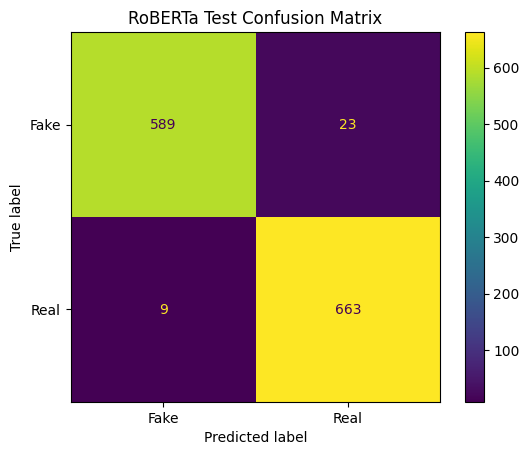

In [34]:
cm = confusion_matrix(
    test_true_labels,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fake', 'Real']
)

disp.plot()
plt.title("RoBERTa Test Confusion Matrix")
plt.show()

In [35]:
precision, recall, f1, _ = precision_recall_fscore_support(
    test_true_labels,
    test_predictions,
    average='weighted',
    zero_division=0
)

roberta_results = pd.DataFrame({
    'Model': ['RoBERTa'],
    'Accuracy': [test_accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

roberta_results

,Model,Accuracy,Precision,Recall,F1 Score
0,RoBERTa,0.975078,0.975279,0.975078,0.975062
